In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import xyzservices as xyz
import coiled
import cartopy
import rioxarray as rxr
import cartopy.crs as ccrs
from cartopy import feature as cfeature
from global_snowmelt_runoff_onset.config import Config, Tile
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import geopandas as gpd
import numpy as np
import zarr

In [2]:
from dask.distributed import Client, LocalCluster

cluster = LocalCluster(
    n_workers=8,
    threads_per_worker=4,
    memory_limit='15GB',       # changed from 10 to 15GB
    local_directory='/tmp/dask-spill',
)
client = Client(cluster)

zarr.config.set({
    'async.concurrency': 128,   # 32 to 128GB
    'threading.max_workers': 16, # codec threads = CPU count
})

client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 111.76 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35685,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36221,Total threads: 4
Dashboard: http://127.0.0.1:37021/status,Memory: 13.97 GiB
Nanny: tcp://127.0.0.1:33429,


In [3]:
config = Config('config/global_config_v9.txt')

SAS token is valid until 2026-08-05 06:31 UTC (539.5 hours)
----------------------------------------
Configuration loaded:
config_name = global_config_v9
version = v9
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 81.099
bbox_bottom = -59.999
wy_start = 2015
wy_end = 2024
low_backscatter_threshold = 0.001
min_monthly_acquisitions = 1
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow.geojson
tile_results_path = processing/tile_data/tile_results_v9.csv
global_runoff_zarr_store_azure_path = snowmelt/snowmelt_runoff_onset/global_v9.zarr
seasonal_snow_mask_zarr_store_azure_path = snowmelt/snow_cover/global_modis_snow_cover.zarr
season

In [4]:
coarsen_factor = 20
store = config.azure_blob_fs.get_mapper(f"snowmelt/snowmelt_runoff_onset/coarsened/global_{config.version}_coarsened_{coarsen_factor}_ds.zarr")
global_coarsened_ds = xr.open_zarr(store, consolidated=True, decode_coords='all',chunks="auto")#{'latitude':3*2048, 'longitude':3*2048}
global_coarsened_ds = global_coarsened_ds.rio.write_crs('EPSG:4326')
global_coarsened_ds

<xarray.Dataset> Size: 34GB
Dimensions:                     (water_year: 10, latitude: 9798,
                                 longitude: 24999)
Coordinates:
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
  * latitude                    (latitude) float64 78kB 81.09 81.08 ... -59.99
  * longitude                   (longitude) float64 200kB -180.0 ... 180.0
    spatial_ref                 int64 8B 0
Data variables:
    runoff_onset                (water_year, latitude, longitude) float32 10GB dask.array<chunksize=(2, 4096, 4096), meta=np.ndarray>
    runoff_onset_mad            (latitude, longitude) float64 2GB dask.array<chunksize=(4096, 4096), meta=np.ndarray>
    runoff_onset_median         (latitude, longitude) float32 980MB dask.array<chunksize=(4096, 4096), meta=np.ndarray>
    temporal_resolution         (water_year, latitude, longitude) float64 20GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    temporal_resolution_median  (latitude, longitude) float64 2GB dask.array<chunksize=(4096, 4096), meta=np.ndarray>
Attributes:
    processed_tiles:  []

In [5]:
global_coarsened_ds = global_coarsened_ds.coarsen(latitude=6, longitude=6, boundary='trim').mean()
global_coarsened_ds

<xarray.Dataset> Size: 952MB
Dimensions:                     (water_year: 10, latitude: 1633, longitude: 4166)
Coordinates:
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
  * latitude                    (latitude) float64 13kB 81.06 80.97 ... -59.95
  * longitude                   (longitude) float64 33kB -180.0 -179.9 ... 179.9
    spatial_ref                 int64 8B 0
Data variables:
    runoff_onset                (water_year, latitude, longitude) float32 272MB dask.array<chunksize=(2, 682, 682), meta=np.ndarray>
    runoff_onset_mad            (latitude, longitude) float64 54MB dask.array<chunksize=(682, 682), meta=np.ndarray>
    runoff_onset_median         (latitude, longitude) float32 27MB dask.array<chunksize=(682, 682), meta=np.ndarray>
    temporal_resolution         (water_year, latitude, longitude) float64 544MB dask.array<chunksize=(1, 341, 341), meta=np.ndarray>
    temporal_resolution_median  (latitude, longitude) float64 54MB dask.array<chunksize=(682, 682), meta=np.ndarray>
Attributes:
    processed_tiles:  []

In [6]:
global_coarsened_ds = global_coarsened_ds.compute()
global_coarsened_ds

<xarray.Dataset> Size: 952MB
Dimensions:                     (water_year: 10, latitude: 1633, longitude: 4166)
Coordinates:
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
  * latitude                    (latitude) float64 13kB 81.06 80.97 ... -59.95
  * longitude                   (longitude) float64 33kB -180.0 -179.9 ... 179.9
    spatial_ref                 int64 8B 0
Data variables:
    runoff_onset                (water_year, latitude, longitude) float32 272MB ...
    runoff_onset_mad            (latitude, longitude) float64 54MB nan ... nan
    runoff_onset_median         (latitude, longitude) float32 27MB nan ... nan
    temporal_resolution         (water_year, latitude, longitude) float64 544MB ...
    temporal_resolution_median  (latitude, longitude) float64 54MB nan ... nan
Attributes:
    processed_tiles:  []

In [8]:
global_hillshade_robinson_da = rxr.open_rasterio('../data/global_hillshade_robinson.tif', masked=True, chunks='auto').squeeze().coarsen(x=10, y=10, boundary='trim').mean().compute()
global_hillshade_robinson_da

<xarray.DataArray (y: 1666, x: 3284)> Size: 22MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1666, 3284), dtype=float32)
Coordinates:
  * y            (y) float64 13kB 8.62e+06 8.61e+06 ... -8.608e+06 -8.618e+06
  * x            (x) float64 26kB -1.7e+07 -1.699e+07 ... 1.698e+07 1.699e+07
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_SOFTWARE:        Adobe Photoshop CS5 Macintosh
    TIFFTAG_DATETIME:        2012:07:20 09:39:49
    TIFFTAG_XRESOLUTION:     72
    TIFFTAG_YRESOLUTION:     72
    TIFFTAG_RESOLUTIONUNIT:  2 (pixels/inch)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0

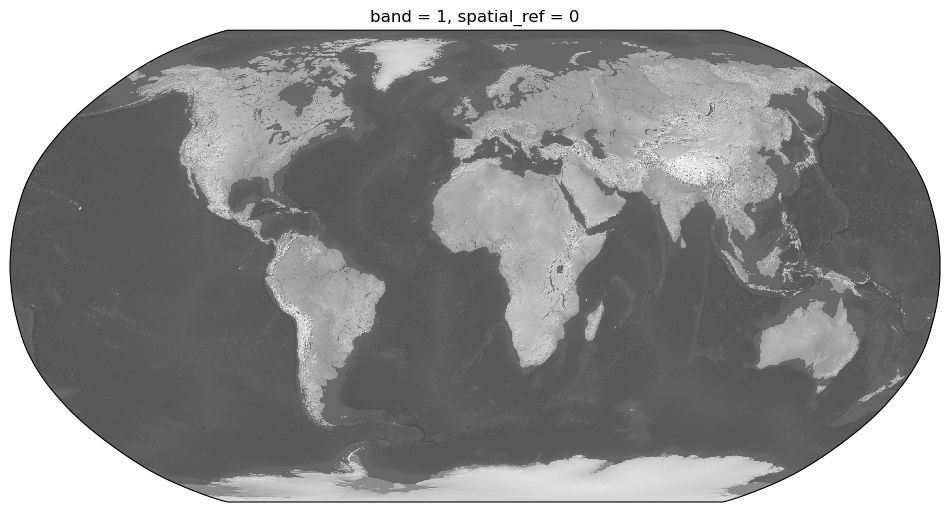

In [9]:
f,ax=plt.subplots(figsize=(12,7),subplot_kw=dict(projection=ccrs.Robinson()))
global_hillshade_robinson_da.plot.imshow(ax=ax, cmap='gray', transform=ccrs.Robinson(), add_colorbar=False)

2015
2016
2017
2018
2019
2020
2021
2022
2023
2024


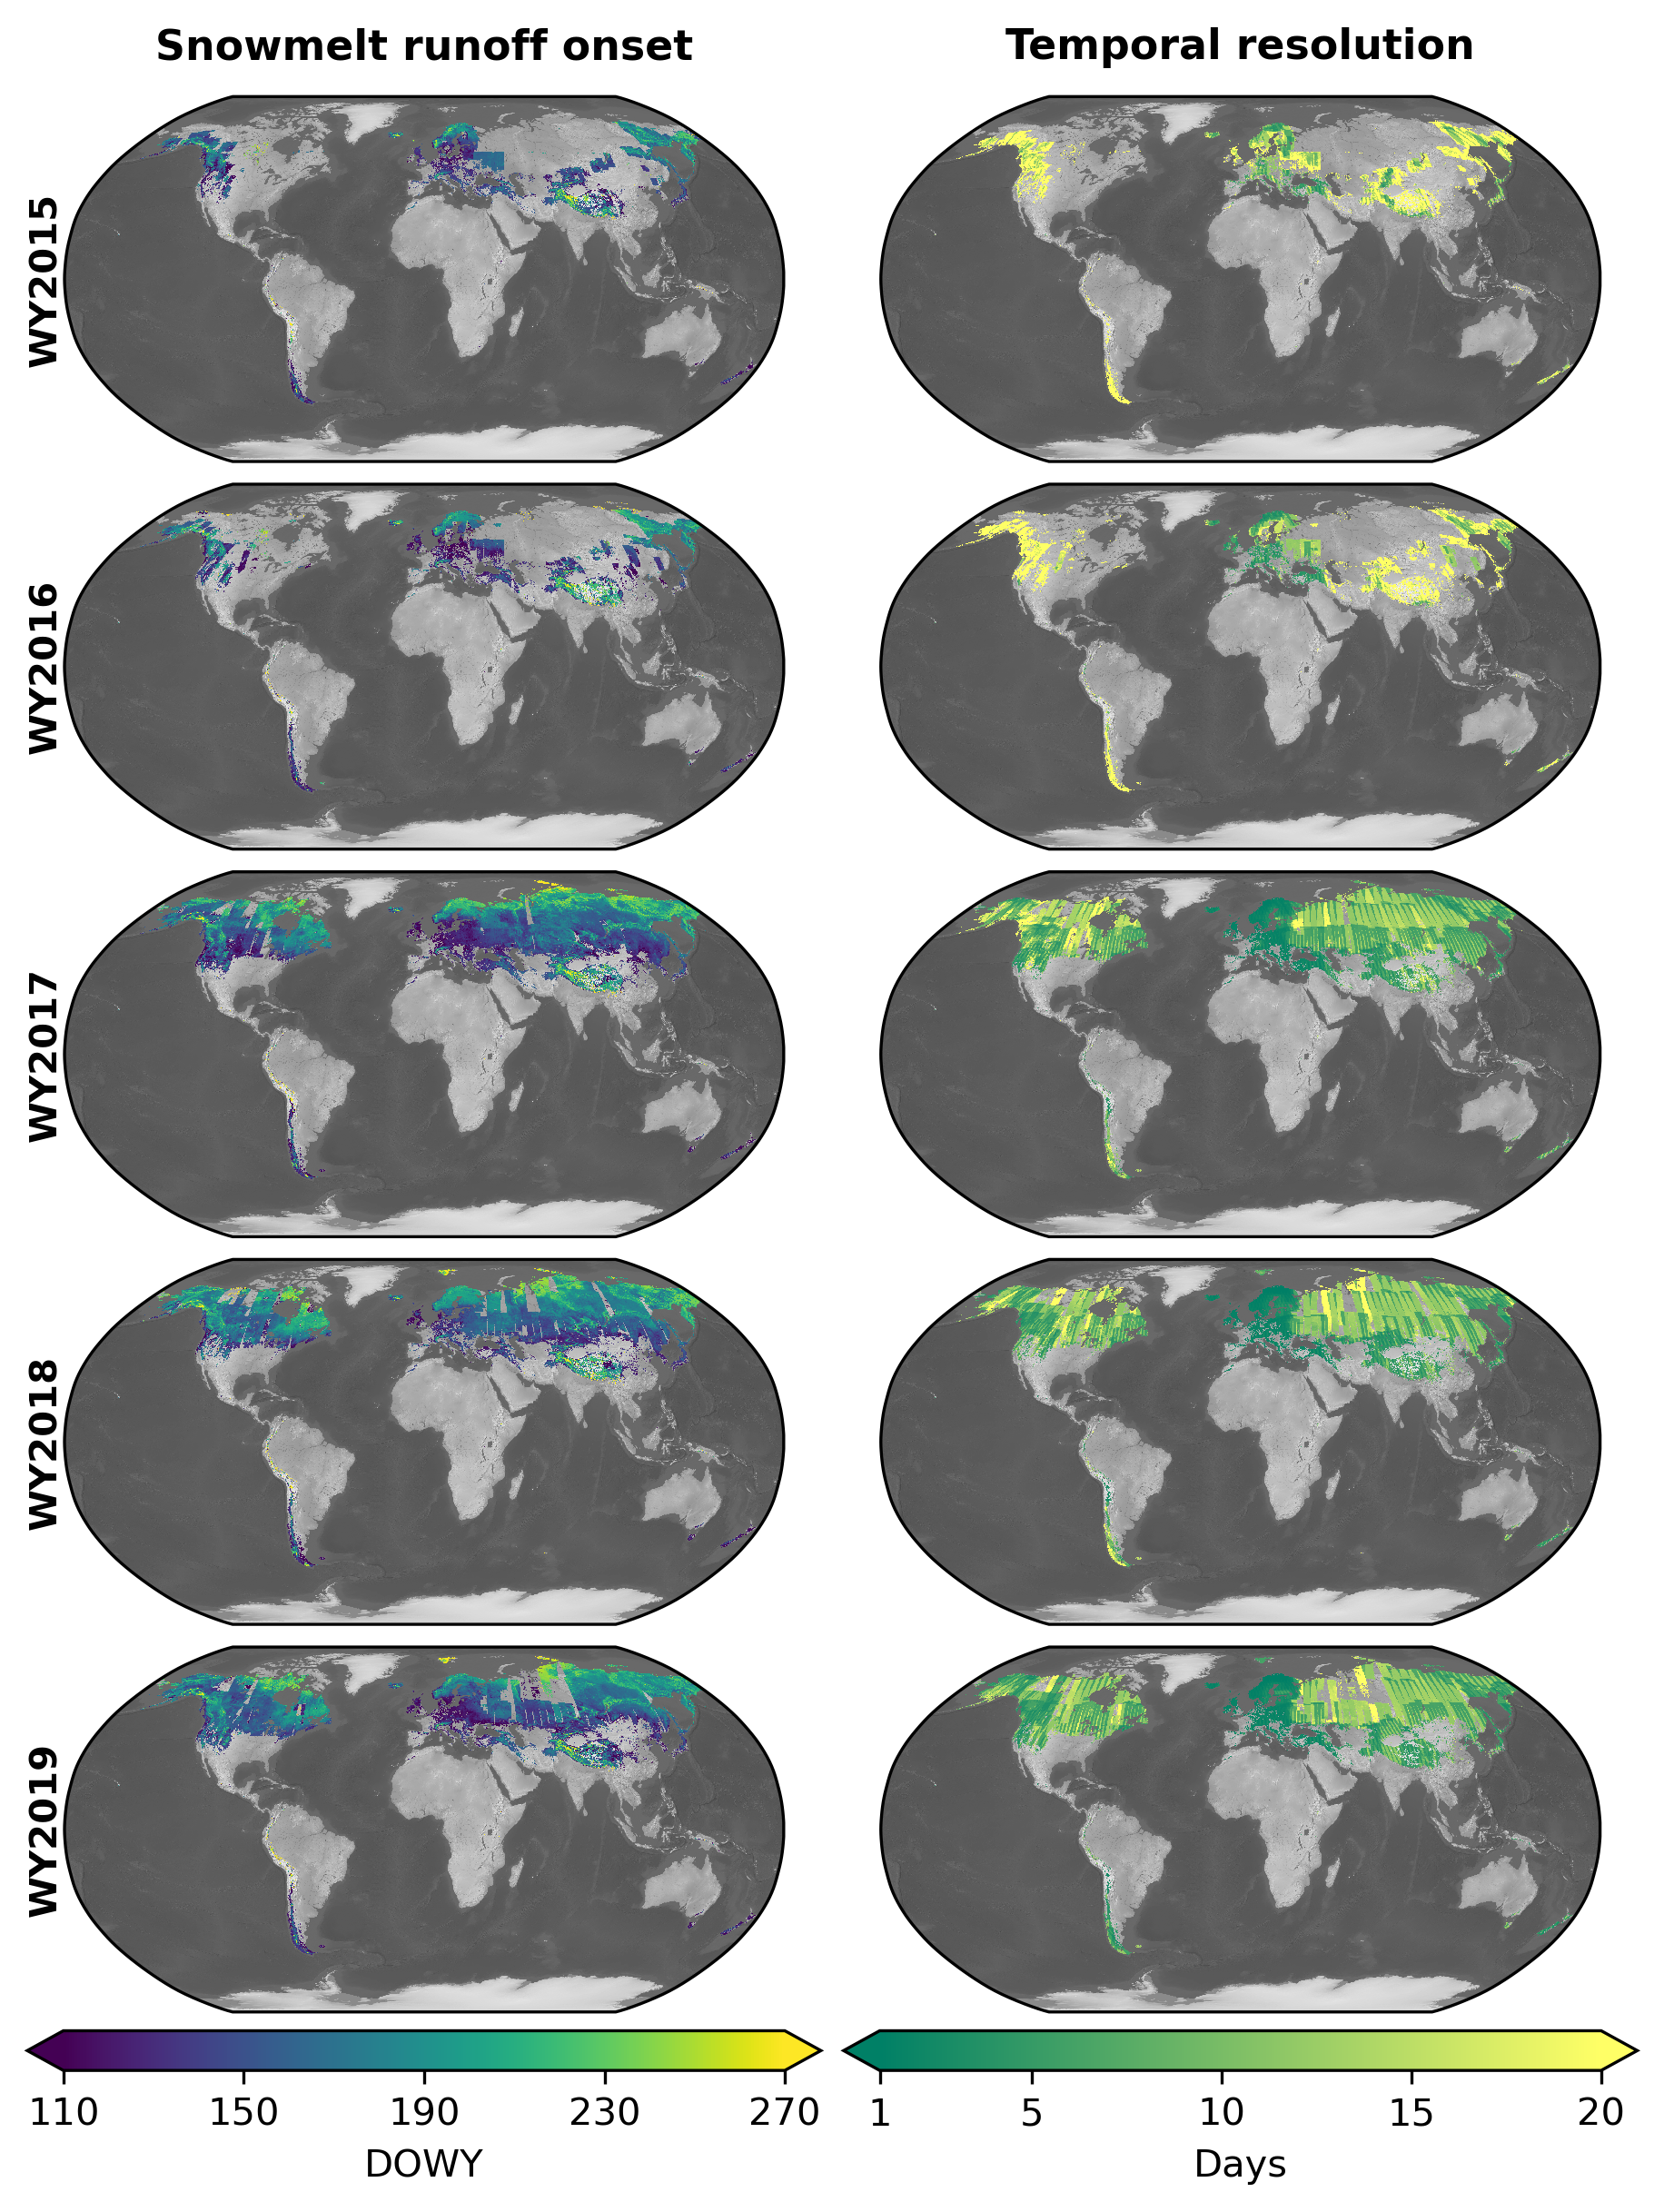

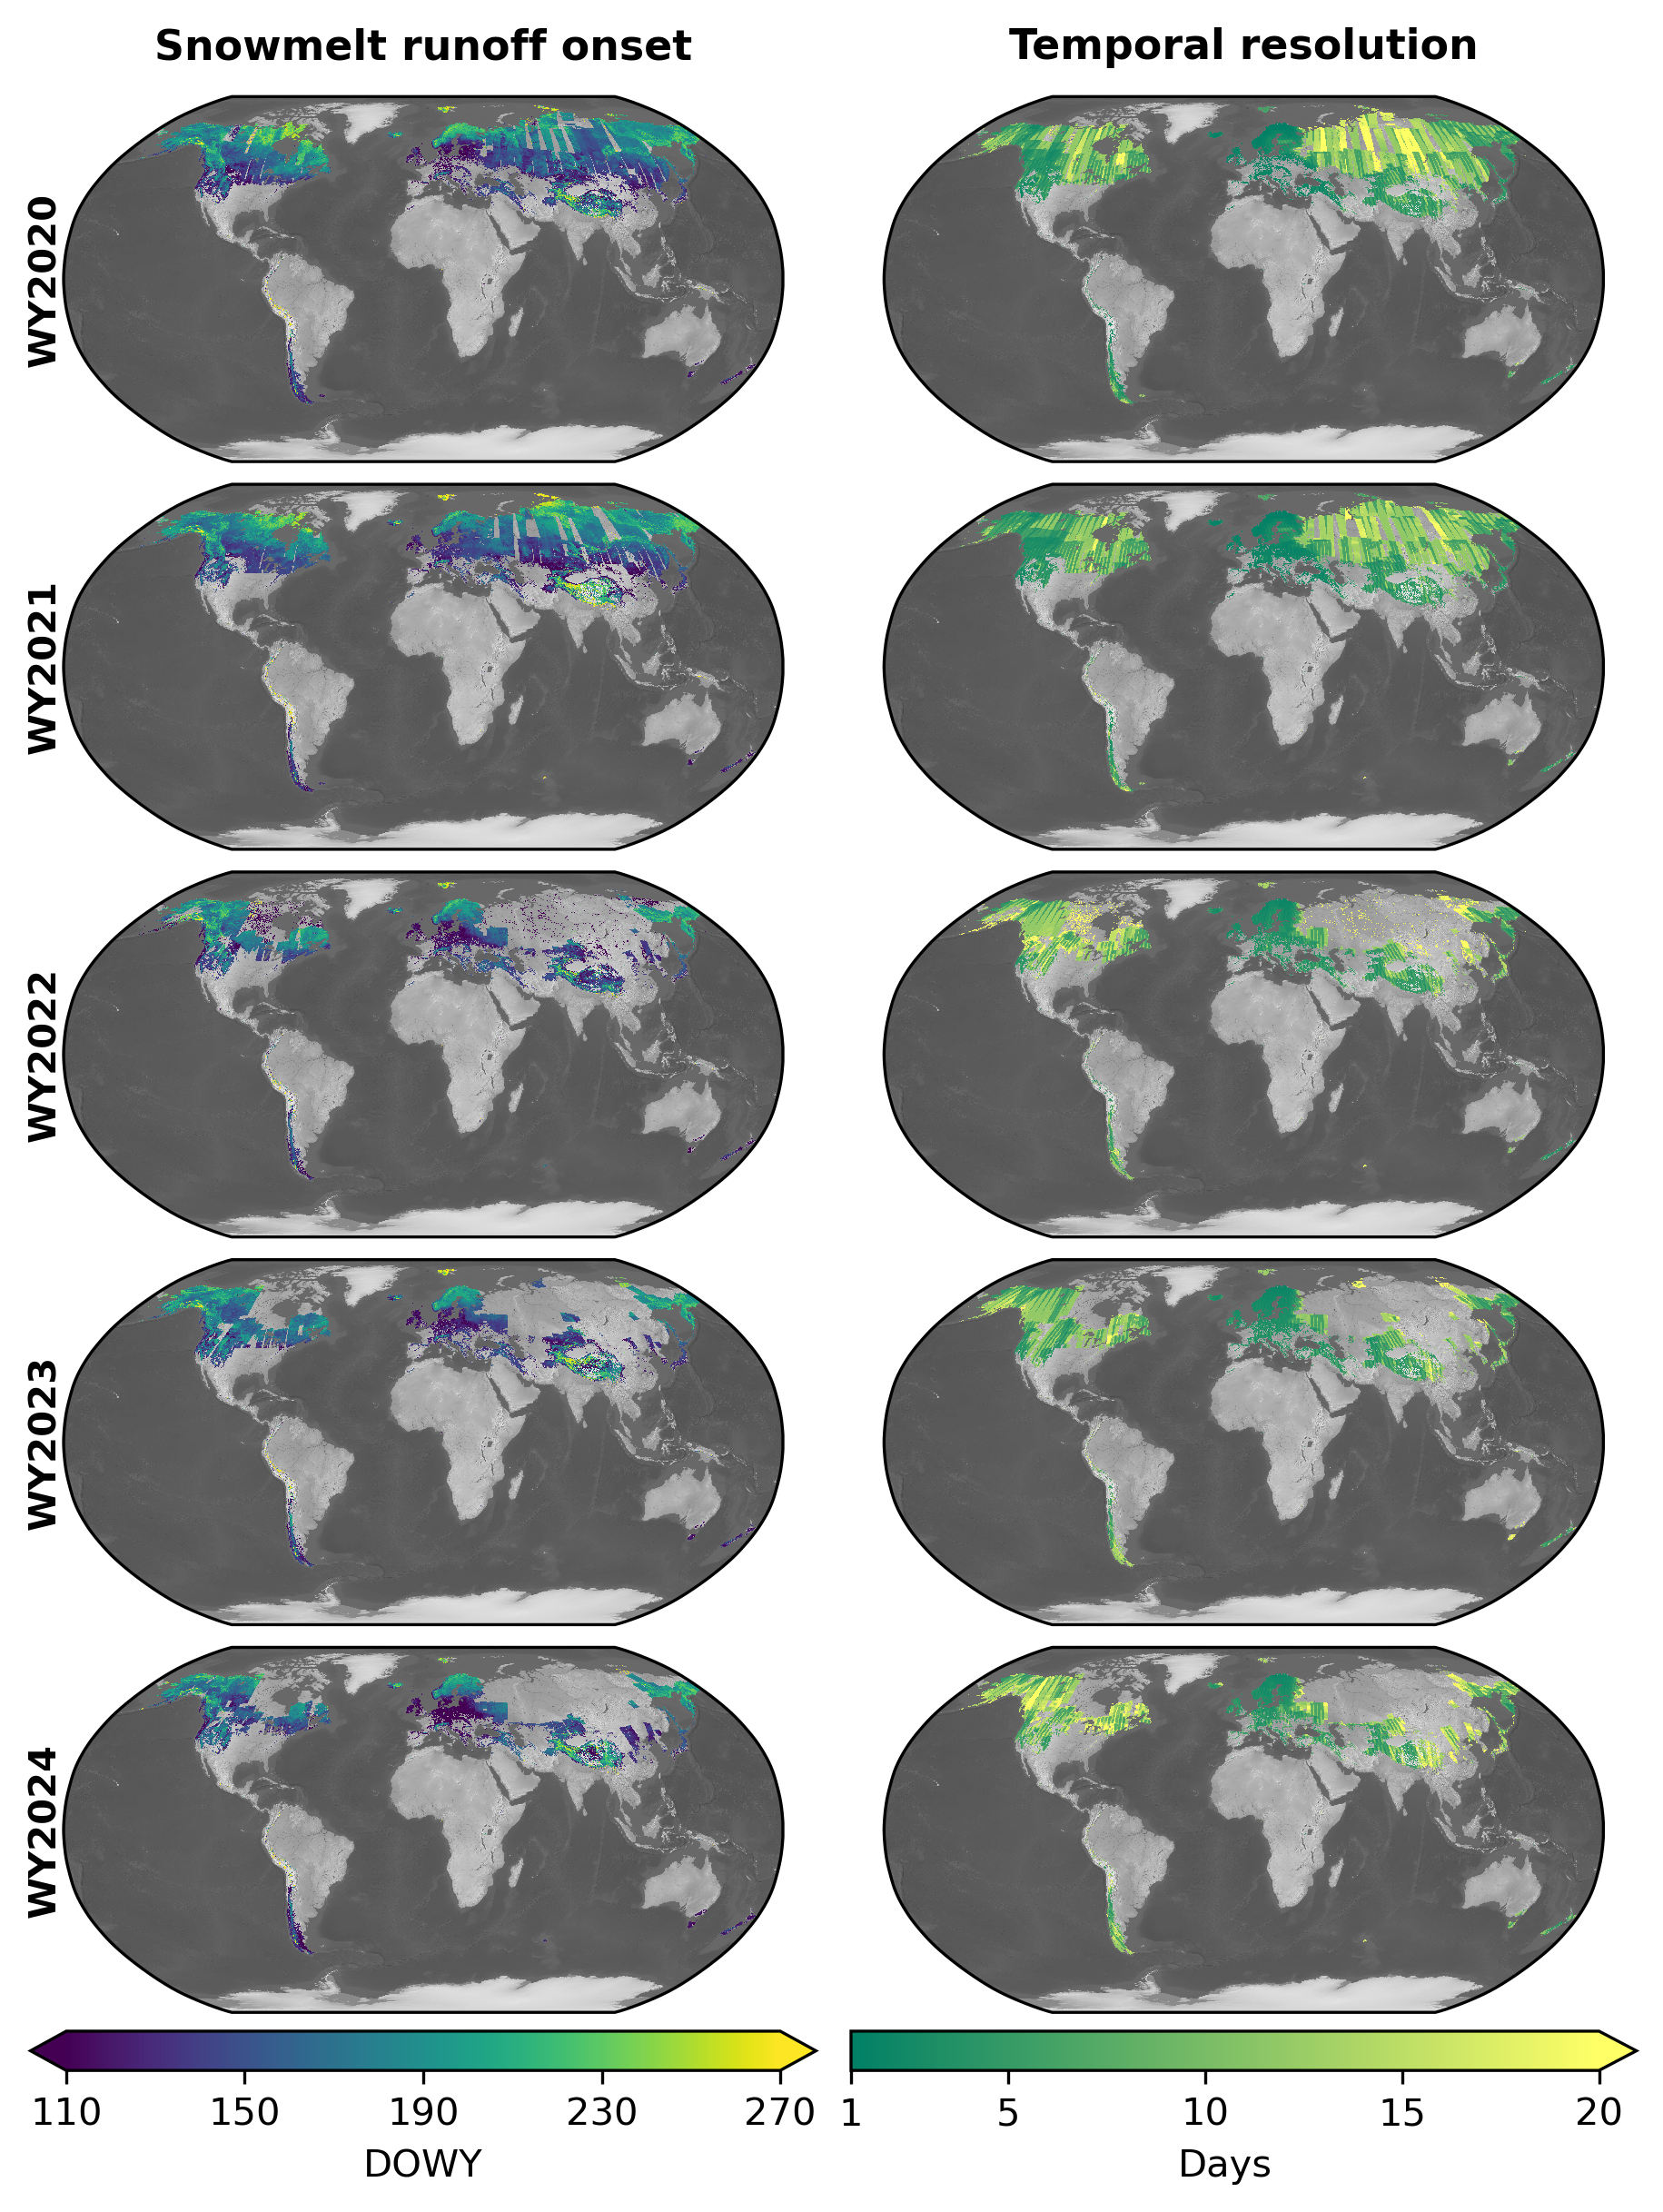

In [10]:
# # First figure: 2015-2019
# f1, axs1 = plt.subplots(nrows=5, ncols=2, figsize=(6,8), 
#                         subplot_kw=dict(projection=ccrs.Robinson()),
#                         dpi=300, layout='constrained')


# dowy_cbar_ticks = [110, 150, 190, 230, 270]
# days_cbar_ticks = [1, 5, 10, 15, 20]

# for water_year in global_coarsened_ds['water_year'].values[:5]:  # 2015-2019
#     print(water_year)
    
#     row_idx = int(water_year) - 2015
    
#     if water_year == 2019:
#         colorbar = True
#         cbar_dowy = {'label':'DOWY','orientation':'horizontal', 'ticks': dowy_cbar_ticks}
#         cbar_days = {'label':'Days','orientation':'horizontal', 'ticks': days_cbar_ticks}
#     else:
#         colorbar = False
#         cbar_dowy = None
#         cbar_days = None
    
#     # Runoff onset
#     ax = axs1[row_idx, 0]
#     global_hillshade_robinson_da.plot.imshow(ax=ax, cmap='gray', 
#                                              transform=ccrs.Robinson(), 
#                                              add_colorbar=False)
    
#     global_coarsened_ds['runoff_onset'].sel(water_year=water_year).plot.imshow(
#         ax=ax,
#         cmap='viridis',
#         vmin=110,
#         vmax=270,
#         transform=ccrs.PlateCarree(),
#         add_colorbar=colorbar,
#         cbar_kwargs=cbar_dowy
#     )
#     ax.set_title('')
    
#     # Add row labels using text
#     ax.text(0, 0.5, f'WY{int(water_year)}', transform=ax.transAxes,
#             fontsize=10, rotation=90,fontweight='bold', va='center', ha='right')
    
#     # Temporal resolution
#     ax = axs1[row_idx, 1]
#     global_hillshade_robinson_da.plot.imshow(ax=ax, cmap='gray', 
#                                              transform=ccrs.Robinson(), 
#                                              add_colorbar=False)
    
#     global_coarsened_ds["temporal_resolution"].sel(water_year=water_year).plot.imshow(
#         ax=ax,
#         cmap="summer",
#         vmin=1,
#         vmax=20,
#         transform=ccrs.PlateCarree(),
#         add_colorbar=colorbar,
#         cbar_kwargs=cbar_days
#     )
#     ax.set_title('')

# # Add column titles
# axs1[0, 0].set_title('Snowmelt runoff onset', fontsize=11, fontweight='bold', pad=10)
# axs1[0, 1].set_title('Temporal resolution', fontsize=11, fontweight='bold', pad=10)

# f1.savefig('figures/global_2015_2019_snowmelt_runoff_onset_and_temporal_res_with_hillshade.png', 
#            dpi=300, bbox_inches='tight')

# # Second figure: 2020-2024
# f2, axs2 = plt.subplots(nrows=5, ncols=2, figsize=(6,8), 
#                         subplot_kw=dict(projection=ccrs.Robinson()),
#                         dpi=300, layout='constrained')

# for water_year in global_coarsened_ds['water_year'].values[5:]:  # 2020-2024
#     print(water_year)
    
#     row_idx = int(water_year) - 2020
    
#     if water_year == 2024:
#         colorbar = True
#         cbar_dowy = {'label':'DOWY','orientation':'horizontal', 'ticks': dowy_cbar_ticks}
#         cbar_days = {'label':'Days','orientation':'horizontal', 'ticks': days_cbar_ticks}
#     else:
#         colorbar = False
#         cbar_dowy = None
#         cbar_days = None
    
#     # Runoff onset
#     ax = axs2[row_idx, 0]
#     global_hillshade_robinson_da.plot.imshow(ax=ax, cmap='gray', 
#                                              transform=ccrs.Robinson(), 
#                                              add_colorbar=False)
    
#     global_coarsened_ds['runoff_onset'].sel(water_year=water_year).plot.imshow(
#         ax=ax,
#         cmap='viridis',
#         vmin=110,
#         vmax=270,
#         transform=ccrs.PlateCarree(),
#         add_colorbar=colorbar,
#         cbar_kwargs=cbar_dowy
#     )
#     ax.set_title('')
    
#     # Add row labels using text
#     ax.text(-0.0, 0.5, f'WY{int(water_year)}', transform=ax.transAxes,
#             fontsize=10, fontweight='bold', rotation=90, va='center', ha='right')
    
#     # Temporal resolution
#     ax = axs2[row_idx, 1]
#     global_hillshade_robinson_da.plot.imshow(ax=ax, cmap='gray', 
#                                              transform=ccrs.Robinson(), 
#                                              add_colorbar=False)
    
#     global_coarsened_ds["temporal_resolution"].sel(water_year=water_year).plot.imshow(
#         ax=ax,
#         cmap="summer",
#         vmin=1,
#         vmax=20,
#         transform=ccrs.PlateCarree(),
#         add_colorbar=colorbar,
#         cbar_kwargs=cbar_days
#     )
#     ax.set_title('')

# # Add column titles
# axs2[0, 0].set_title('Snowmelt runoff onset', fontsize=11, fontweight='bold', pad=10)
# axs2[0, 1].set_title('Temporal resolution', fontsize=11, fontweight='bold', pad=10)

# f2.savefig('figures/global_2020_2024_snowmelt_runoff_onset_and_temporal_res_with_hillshade.png', 
#            dpi=300, bbox_inches='tight')

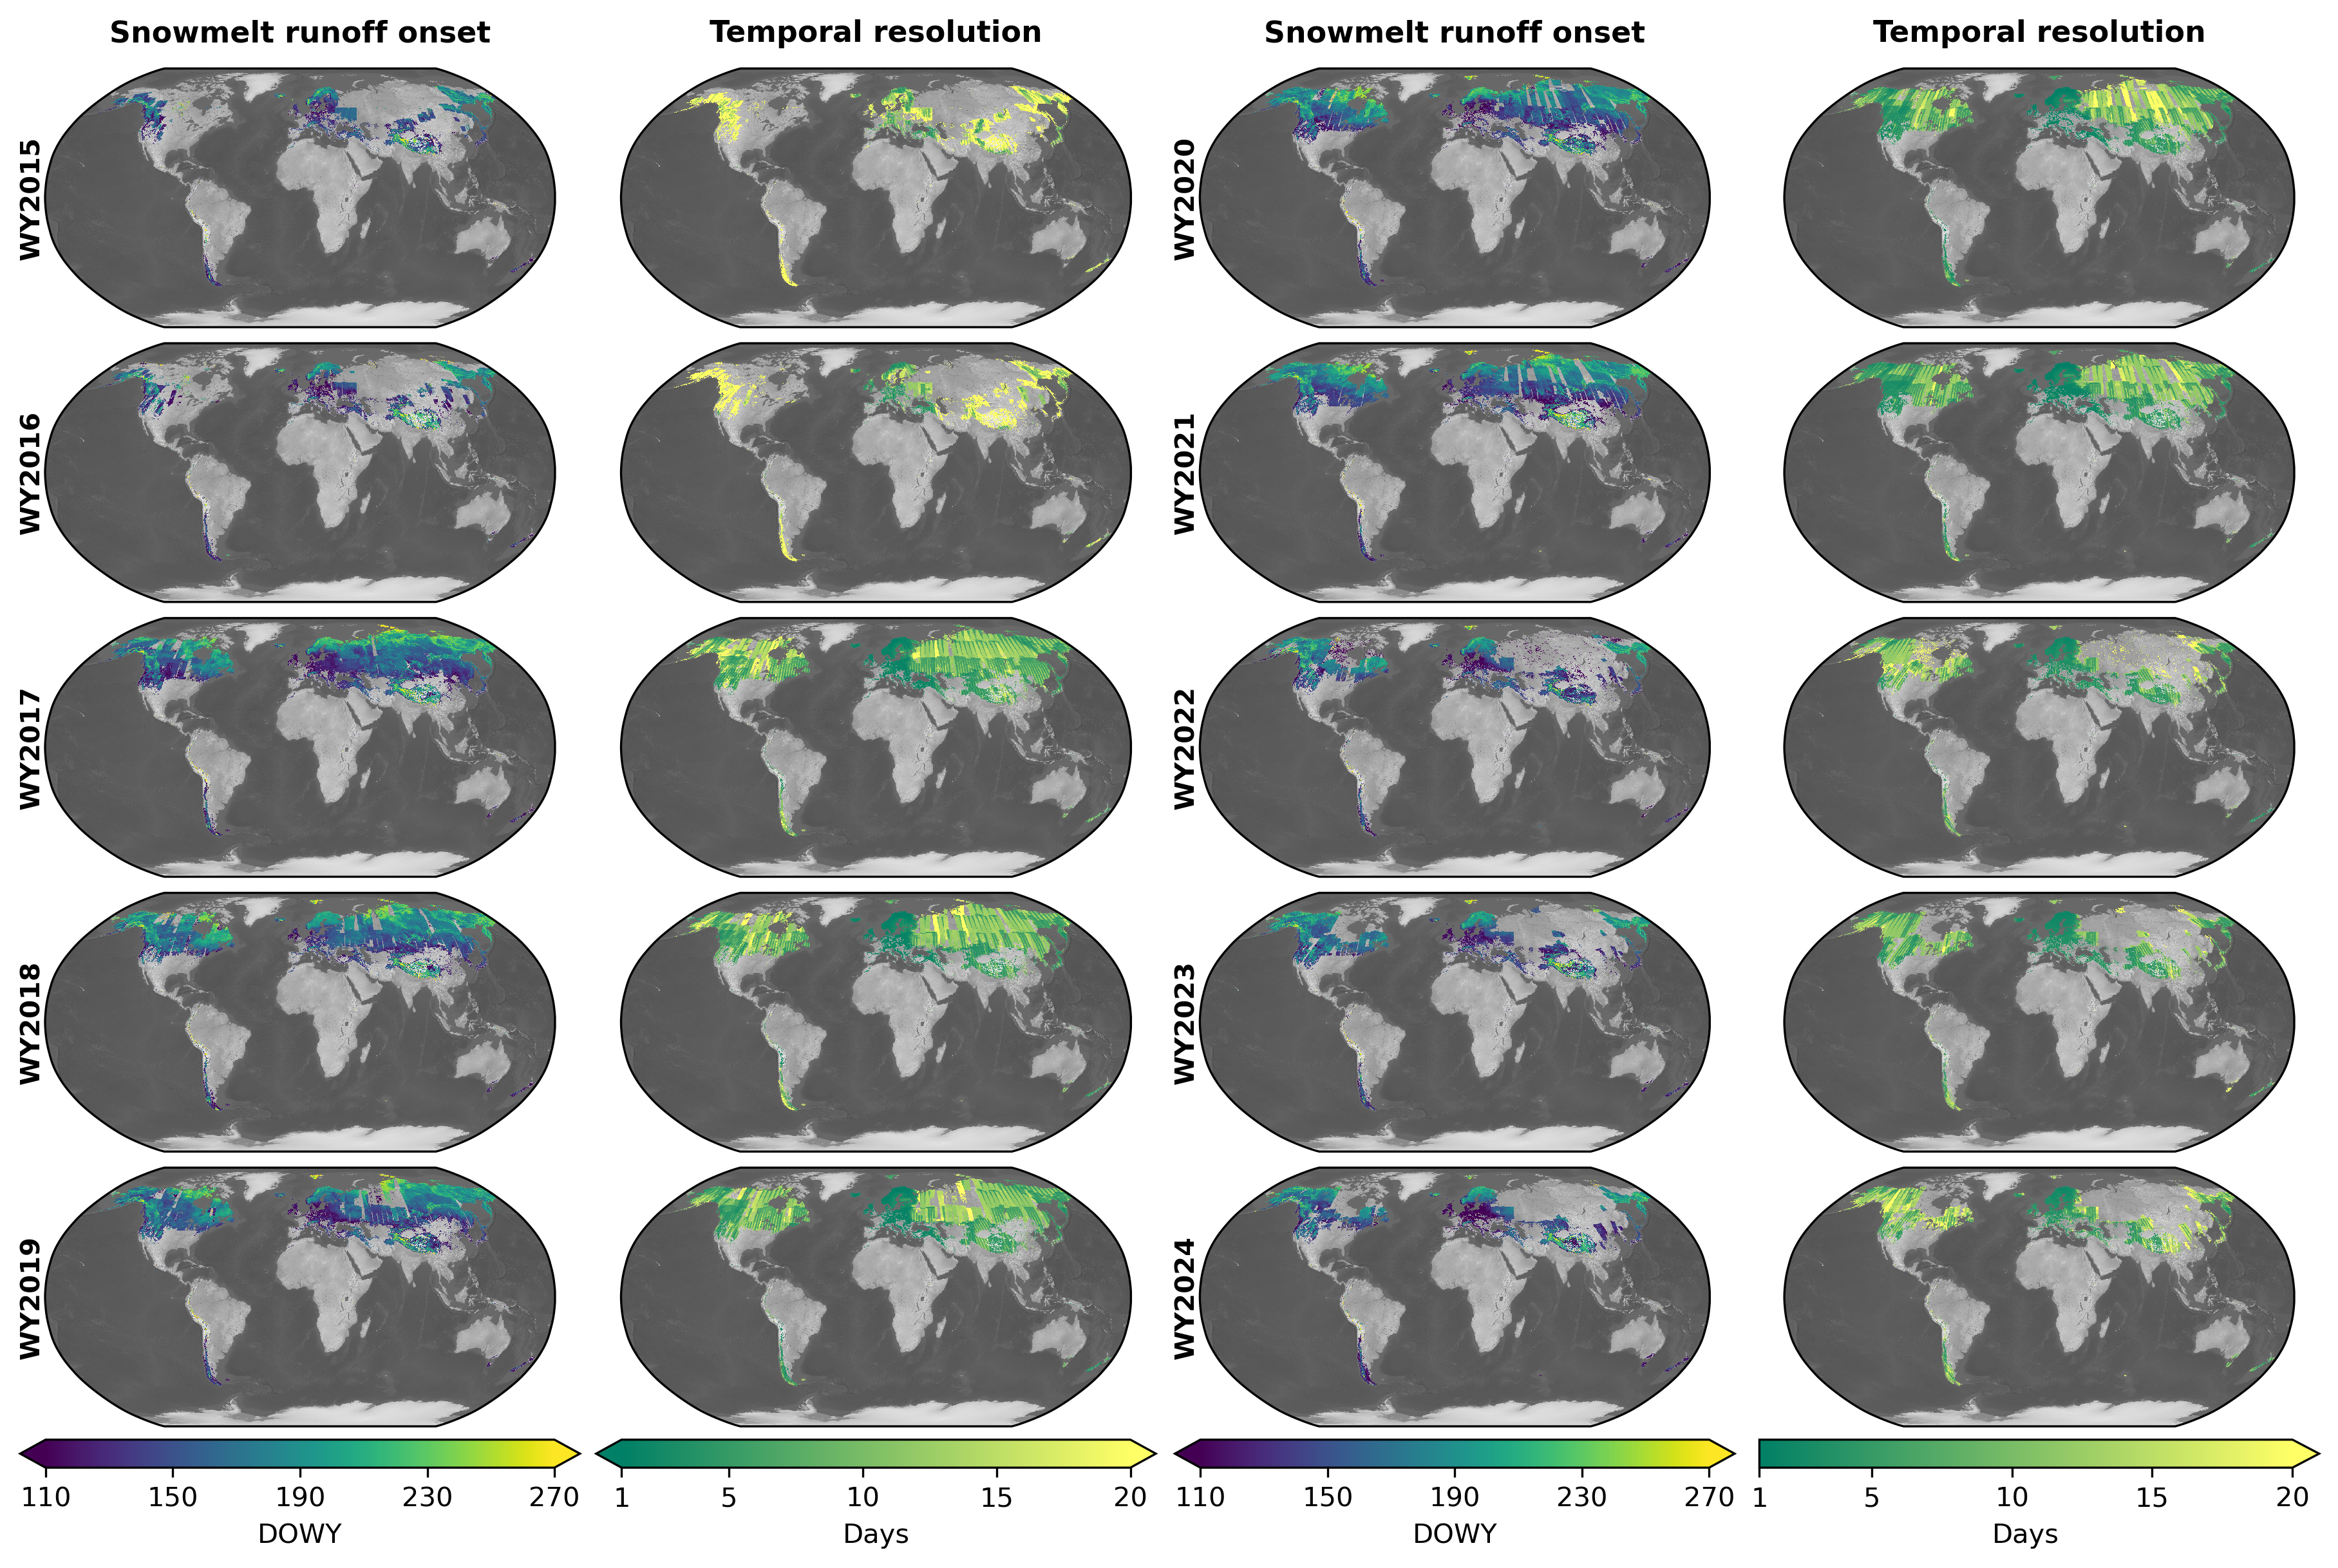

In [11]:
dowy_cbar_ticks = [110, 150, 190, 230, 270]
days_cbar_ticks = [1, 5, 10, 15, 20]

f, axs = plt.subplots(nrows=5, ncols=4, figsize=(12, 8),
                      subplot_kw=dict(projection=ccrs.Robinson()),
                      dpi=300, layout='constrained')

for water_year in global_coarsened_ds['water_year'].values[:5]:  # 2015-2019
    row_idx = int(water_year) - 2015
    colorbar = water_year == 2019
    cbar_dowy = {'label': 'DOWY', 'orientation': 'horizontal', 'ticks': dowy_cbar_ticks} if colorbar else None
    cbar_days = {'label': 'Days', 'orientation': 'horizontal', 'ticks': days_cbar_ticks} if colorbar else None

    ax = axs[row_idx, 0]
    global_hillshade_robinson_da.plot.imshow(ax=ax, cmap='gray', transform=ccrs.Robinson(), add_colorbar=False)
    global_coarsened_ds['runoff_onset'].sel(water_year=water_year).plot.imshow(
        ax=ax, cmap='viridis', vmin=110, vmax=270,
        transform=ccrs.PlateCarree(), add_colorbar=colorbar, cbar_kwargs=cbar_dowy)
    ax.set_title('')
    ax.text(0, 0.5, f'WY{int(water_year)}', transform=ax.transAxes,
            fontsize=10, rotation=90, fontweight='bold', va='center', ha='right')

    ax = axs[row_idx, 1]
    global_hillshade_robinson_da.plot.imshow(ax=ax, cmap='gray', transform=ccrs.Robinson(), add_colorbar=False)
    global_coarsened_ds['temporal_resolution'].sel(water_year=water_year).plot.imshow(
        ax=ax, cmap='summer', vmin=1, vmax=20,
        transform=ccrs.PlateCarree(), add_colorbar=colorbar, cbar_kwargs=cbar_days)
    ax.set_title('')

for water_year in global_coarsened_ds['water_year'].values[5:]:  # 2020-2024
    row_idx = int(water_year) - 2020
    colorbar = water_year == 2024
    cbar_dowy = {'label': 'DOWY', 'orientation': 'horizontal', 'ticks': dowy_cbar_ticks} if colorbar else None
    cbar_days = {'label': 'Days', 'orientation': 'horizontal', 'ticks': days_cbar_ticks} if colorbar else None

    ax = axs[row_idx, 2]
    global_hillshade_robinson_da.plot.imshow(ax=ax, cmap='gray', transform=ccrs.Robinson(), add_colorbar=False)
    global_coarsened_ds['runoff_onset'].sel(water_year=water_year).plot.imshow(
        ax=ax, cmap='viridis', vmin=110, vmax=270,
        transform=ccrs.PlateCarree(), add_colorbar=colorbar, cbar_kwargs=cbar_dowy)
    ax.set_title('')
    ax.text(0, 0.5, f'WY{int(water_year)}', transform=ax.transAxes,
            fontsize=10, rotation=90, fontweight='bold', va='center', ha='right')

    ax = axs[row_idx, 3]
    global_hillshade_robinson_da.plot.imshow(ax=ax, cmap='gray', transform=ccrs.Robinson(), add_colorbar=False)
    global_coarsened_ds['temporal_resolution'].sel(water_year=water_year).plot.imshow(
        ax=ax, cmap='summer', vmin=1, vmax=20,
        transform=ccrs.PlateCarree(), add_colorbar=colorbar, cbar_kwargs=cbar_days)
    ax.set_title('')

axs[0, 0].set_title('Snowmelt runoff onset', fontsize=11, fontweight='bold', pad=10)
axs[0, 1].set_title('Temporal resolution', fontsize=11, fontweight='bold', pad=10)
axs[0, 2].set_title('Snowmelt runoff onset', fontsize=11, fontweight='bold', pad=10)
axs[0, 3].set_title('Temporal resolution', fontsize=11, fontweight='bold', pad=10)

f.savefig('figures/global_2015_2024_snowmelt_runoff_onset_and_temporal_res_with_hillshade.png',
          dpi=300, bbox_inches='tight')